# 🕌 Arabic NLP Text Classification — Best Practices Notebook

This notebook walks through a **complete Arabic NLP pipeline** from raw data ingestion to multiple classification tasks using at least **3 different models**.

## Pipeline Overview
1. 📥 **Dataset & Corpus Reading** — Load Arabic text data
2. 🧹 **Arabic Text Preprocessing** — Normalization, tokenization, stop-word removal
3. 📐 **Vectorization** — BoW, TF-IDF, AraBERT embeddings
4. 🏷️ **Classification Tasks**
   - Sentiment Analysis (تحليل المشاعر)
   - Topic / News Classification (تصنيف المواضيع)
   - Dialect Identification (تحديد اللهجة)
5. 🤖 **Models Used**
   - Model 1: Multinomial Naive Bayes (baseline)
   - Model 2: Support Vector Machine (SVM)
   - Model 3: AraBERT (transformer fine-tuning)
6. 📊 **Evaluation & Comparison**

---
> **Note:** Arabic is a morphologically rich, right-to-left language with diacritics, dialectal variance, and complex root-pattern structures. Each preprocessing step below addresses these specific challenges.

## ⚙️ Cell 0 — Install & Import Dependencies

In [ ]:
# ── Install required packages ──────────────────────────────────────────────
# Run this cell once (restart kernel after installation)
!pip install -q arabert==1.0.1 pyarabic camel-tools transformers datasets
!pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm
!pip install -q torch torchvision  # or tensorflow if preferred

In [1]:
# ── Core libraries ─────────────────────────────────────────────────────────
import re
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'  # Fallback; use 'Scheherazade' for production

# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── Hugging Face ───────────────────────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset

print('✅ All imports successful')

✅ All imports successful


---
## 📥 Section 1 — Dataset & Corpus Reading

### Arabic NLP Benchmark Datasets

| Dataset | Task | Size | Source |
|---------|------|------|--------|
| **ASTD** | Sentiment (3-class) | 10k tweets | Nabil et al., 2015 |
| **HARD** | Sentiment (2-class) | 94k hotel reviews | Elnagar et al., 2018 |
| **ANERcorp** | NER | 150k tokens | — |
| **OSAC** | Topic classification | 22k docs | Saad & Ashour, 2010 |
| **MADAR** | Dialect ID | 25 dialects | Bouamor et al., 2019 |
| **ArSAS** | Sentiment + Sarcasm | 21k tweets | Farha & Magdy, 2019 |


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
#  Option A: Load from a local CSV file
#  Expected columns: 'text' (Arabic string) and 'label' (class name or int)
# ═══════════════════════════════════════════════════════════════════════════
# df = pd.read_csv('path/to/arabic_dataset.csv')

# ═══════════════════════════════════════════════════════════════════════════
#  Option B: Load from Hugging Face Hub (no download needed)
# ═══════════════════════════════════════════════════════════════════════════
from datasets import load_dataset

# Example: HARD hotel-review sentiment dataset
# hf_ds = load_dataset('asas-ai/hard', split='train')
# df = hf_ds.to_pandas()

# ═══════════════════════════════════════════════════════════════════════════
#  DEMO: Synthetic Arabic corpus (replace with real data in production)
# ═══════════════════════════════════════════════════════════════════════════
demo_data = {
    'text': [
        # --- Original ---
        'المنتج رائع جداً وأنصح الجميع بشرائه',
        'تجربة سيئة للغاية لن أعود لهذا المكان',
        'الخدمة كانت جيدة لكن السعر مرتفع',
        'أفضل فندق نزلت فيه في حياتي',
        'جودة رديئة ولا أنصح أحداً بهذا المنتج',
        'الغرفة نظيفة والموقع ممتاز',
        'خدمة العملاء بطيئة جداً',
        'المطعم يقدم طعاماً لذيذاً بأسعار معقولة',
        'التوصيل تأخر كثيراً والمنتج تالف',
        'تجربة عادية لا بأس بها',

        'منتج ممتاز وجودته عالية جداً',
        'أسوأ تجربة مررت بها في هذا المكان',
        'الخدمة مقبولة لكن الأسعار مبالغ فيها',
        'فندق رائع وخدمة ممتازة جداً',
        'منتج سيء للغاية ولا يستحق الشراء',
        'المكان نظيف جداً وموقعه رائع',
        'الدعم الفني بطيء في الرد',
        'الأكل شهي والخدمة جيدة',
        'الطلب وصل متأخراً وكان فيه عيوب',
        'تجربة مقبولة بشكل عام',

        'أعجبني المنتج كثيراً وأنصح به',
        'خدمة سيئة وتعامل غير محترم',
        'الأداء جيد ولكن السعر مرتفع قليلاً',
        'إقامة ممتازة وتجربة لا تُنسى',
        'الخامة ضعيفة والجودة غير مرضية',
        'الغرفة مرتبة والخدمة ممتازة',
        'الاستجابة بطيئة جداً من الفريق',
        'الوجبات لذيذة والأسعار مناسبة',
        'التوصيل سيء والمنتج وصل متضرر',
        'تجربة عادية ولم تكن مميزة'
    ],

    'label': [
        'positive','negative','neutral','positive',
        'negative','positive','negative','positive',
        'negative','neutral',

        'positive','negative','neutral','positive',
        'negative','positive','negative','positive',
        'negative','neutral',

        'positive','negative','neutral','positive',
        'negative','positive','negative','positive',
        'negative','neutral'
    ]
}
df = pd.DataFrame(demo_data)
print(f'📊 Dataset shape: {df.shape}')
print(f'📝 Columns: {list(df.columns)}')
df.head()

📊 Dataset shape: (30, 2)
📝 Columns: ['text', 'label']


,text,label
0,المنتج رائع جداً وأنصح الجميع بشرائه,positive
1,تجربة سيئة للغاية لن أعود لهذا المكان,negative
2,الخدمة كانت جيدة لكن السعر مرتفع,neutral
3,أفضل فندق نزلت فيه في حياتي,positive
4,جودة رديئة ولا أنصح أحداً بهذا المنتج,negative


=== Class Distribution ===
label
positive    12
negative    12
neutral      6
Name: count, dtype: int64


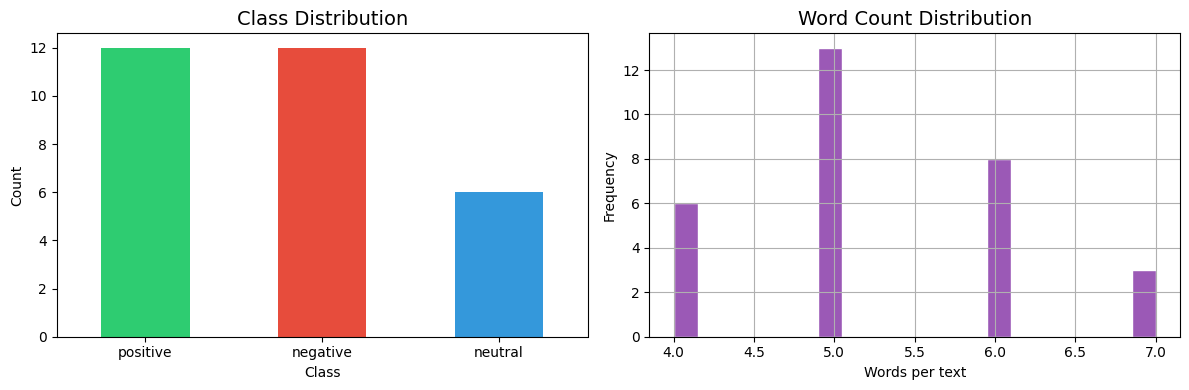


Average text length: 29.3 chars, 5.3 words


In [19]:
# ── Exploratory Data Analysis (EDA) ───────────────────────────────────────
print('=== Class Distribution ===')
print(df['label'].value_counts())

# Text length analysis
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c','#3498db'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Word count distribution
df['word_count'].hist(bins=20, ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Word Count Distribution', fontsize=14)
axes[1].set_xlabel('Words per text')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'\nAverage text length: {df["char_len"].mean():.1f} chars, {df["word_count"].mean():.1f} words')

---
## 🧹 Section 2 — Arabic Text Preprocessing

Arabic-specific challenges:
- **Diacritics (تشكيل):** Harakat marks that change meaning but add noise
- **Hamza forms:** أ / إ / آ / ا are often written interchangeably
- **Tatweel (ـ):** Elongation character (e.g., رائعـــ)
- **Dialectal spelling:** Gulf, Egyptian, Levantine variants
- **Morphological richness:** A single root can produce dozens of derived forms
- **Tokenization:** Clitics (وال، بال، كال) are attached to words

In [20]:
# ── Arabic Unicode ranges & normalization patterns ─────────────────────────

# Arabic stop words (common list — expand as needed)
ARABIC_STOP_WORDS = {
    'في', 'من', 'إلى', 'على', 'وفي', 'هذا', 'هذه', 'ذلك', 'تلك',
    'التي', 'الذي', 'هو', 'هي', 'أن', 'كان', 'كانت', 'لا', 'لم',
    'ما', 'مع', 'عن', 'قد', 'لقد', 'وقد', 'أو', 'بل', 'لكن', 'إذا',
    'حتى', 'كل', 'بعض', 'فقط', 'قبل', 'بعد', 'عند', 'فيها', 'فيه',
    'منها', 'منه', 'عليها', 'عليه', 'وكان', 'وكانت', 'ولا', 'وما',
    'أي', 'كما', 'مما', 'لهذا', 'لكي', 'بهذا', 'هناك', 'هنا', 'ثم'
}

def normalize_arabic(text: str) -> str:
    """
    Step-by-step Arabic text normalization.
    Returns cleaned, normalized Arabic string.
    """
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 2. Remove mentions and hashtags (for social media data)
    text = re.sub(r'@\w+|#\w+', '', text)

    # 3. Remove non-Arabic characters (keep spaces)
    #    Arabic Unicode block: \u0600–\u06FF
    #    Arabic Supplement: \u0750–\u077F
    #    Arabic Extended-A: \u08A0–\u08FF
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\s]', ' ', text)

    # 4. Remove diacritics (Harakat — تشكيل)
    #    Range: \u064B–\u065F (Fathah, Dammah, Kasrah, Sukun, Shadda, etc.)
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)

    # 5. Remove Tatweel (elongation character ـ = \u0640)
    text = re.sub(r'\u0640', '', text)

    # 6. Normalize Alef variants → bare Alef ا
    text = re.sub(r'[أإآ]', 'ا', text)  # \u0623 \u0625 \u0622 → \u0627

    # 7. Normalize Hamza on Ya → Ya without dots (ى)
    text = re.sub(r'ئ', 'ي', text)

    # 8. Normalize Ta Marbuta → Ha (ة → ه)
    #    Comment out if morphological distinction is important
    text = re.sub(r'ة', 'ه', text)

    # 9. Normalize Waw Hamza (ؤ → و)
    text = re.sub(r'ؤ', 'و', text)

    # 10. Collapse multiple whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def remove_stopwords(text: str, stop_words: set = ARABIC_STOP_WORDS) -> str:
    """Remove Arabic stop words from tokenized text."""
    tokens = text.split()
    return ' '.join(tok for tok in tokens if tok not in stop_words)


def arabic_preprocess(text: str, use_stopwords: bool = True) -> str:
    """
    Full Arabic preprocessing pipeline:
      normalize → (optional stop-word removal)
    """
    text = normalize_arabic(text)
    if use_stopwords:
        text = remove_stopwords(text)
    return text


# ── Demo ──────────────────────────────────────────────────────────────────
sample = 'المُنتَجُ رائِعٌ جِدّاً وأنصحُ الجميعَ بشِرائِهِ!!! 😊 https://example.com'
print('Original :', sample)
print('Normalized:', normalize_arabic(sample))
print('Cleaned   :', arabic_preprocess(sample))

Original : المُنتَجُ رائِعٌ جِدّاً وأنصحُ الجميعَ بشِرائِهِ!!! 😊 https://example.com
Normalized: المنتج رايع جدا وانصح الجميع بشرايه
Cleaned   : المنتج رايع جدا وانصح الجميع بشرايه


In [21]:
# ── Optional: Stemming / Light Stemming with ISRIStemmer ──────────────────
# ISRIStemmer is an Arabic stemmer included in NLTK
# Light stemming is preferred over aggressive stemming for Arabic
# because it preserves more morphological information.

try:
    import nltk
    nltk.download('punkt', quiet=True)
    from nltk.stem.isri import ISRIStemmer

    stemmer = ISRIStemmer()

    def stem_arabic(text: str) -> str:
        tokens = text.split()
        stemmed = [stemmer.stem(tok) for tok in tokens]
        return ' '.join(stemmed)

    print('ISRIStemmer demo:')
    test_words = ['يكتبون', 'مكتوب', 'كاتب', 'كتابة']
    for w in test_words:
        print(f'  {w} → {stemmer.stem(w)}')

except ImportError:
    print('nltk not installed; stemming skipped')

ISRIStemmer demo:
  يكتبون → كتب
  مكتوب → كتب
  كاتب → كتب
  كتابة → كتب


In [22]:
# ── Optional: Morphological Analysis with CAMeL Tools ─────────────────────
# CAMeL Tools provides state-of-the-art Arabic tokenization and morphology.
# It handles clitics (وال، كال، بال) and dialectal variants.

# from camel_tools.tokenizers.word import simple_word_tokenize
# from camel_tools.morphology.analyzer import Analyzer
# analyzer = Analyzer.builtin_analyzer()

# def camel_tokenize(text: str) -> list:
#     return simple_word_tokenize(text)

# print(camel_tokenize('والطلاب يتعلمون في المدرسة'))
# Expected: ['و', 'ال', 'طلاب', 'يتعلمون', 'في', 'ال', 'مدرسة']

print('ℹ️  CAMeL Tools section (uncomment to use with: pip install camel-tools)')

ℹ️  CAMeL Tools section (uncomment to use with: pip install camel-tools)


In [23]:
# ── Apply preprocessing to entire DataFrame ────────────────────────────────
tqdm.pandas()

df['clean_text'] = df['text'].progress_apply(arabic_preprocess)

# Label encoding
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
id2label  = {v: k for k, v in label_map.items()}
df['label_id'] = df['label'].map(label_map)

print('✅ Preprocessing complete')
df[['text', 'clean_text', 'label']].head()

  0%|          | 0/30 [00:00<?, ?it/s]

✅ Preprocessing complete


,text,clean_text,label
0,المنتج رائع جداً وأنصح الجميع بشرائه,المنتج رايع جدا وانصح الجميع بشرايه,positive
1,تجربة سيئة للغاية لن أعود لهذا المكان,تجربه سييه للغايه لن اعود المكان,negative
2,الخدمة كانت جيدة لكن السعر مرتفع,الخدمه جيده السعر مرتفع,neutral
3,أفضل فندق نزلت فيه في حياتي,افضل فندق نزلت حياتي,positive
4,جودة رديئة ولا أنصح أحداً بهذا المنتج,جوده ردييه انصح احدا المنتج,negative


---
## 📐 Section 3 — Vectorization

Three strategies for converting Arabic text to numeric features:

| Method | Type | Arabic Consideration |
|--------|------|---------------------|
| **Bag of Words (BoW)** | Sparse, high-dim | Works after normalization |
| **TF-IDF** | Sparse, high-dim | Best for MSA vs. dialectal |
| **AraBERT embeddings** | Dense, 768-dim | Handles morphology contextually |

In [25]:
# ── Train / Test split (stratified to preserve class balance) ──────────────
X = df['clean_text']
y = df['label_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train size : {len(X_train)}')
print(f'Test  size : {len(X_test)}')

Train size : 24
Test  size : 6


In [26]:
# ── TF-IDF Vectorizer (Arabic-aware settings) ──────────────────────────────
# Key parameters for Arabic:
#  - analyzer='word': word-level (better for MSA after normalization)
#  - ngram_range=(1,2): unigrams + bigrams capture compound expressions
#  - min_df=2: ignore very rare words (typos, transliteration)
#  - sublinear_tf=True: log-scale TF to reduce effect of very frequent words

tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=1,             # use min_df=2 or higher on larger datasets
    max_features=50_000,  # cap vocabulary size
    sublinear_tf=True,
    strip_accents=None,   # already handled by normalize_arabic()
)

# IMPORTANT: fit ONLY on training data to prevent data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulary size : {len(tfidf.vocabulary_):,}')
print(f'Train matrix    : {X_train_tfidf.shape}')
print(f'Test  matrix    : {X_test_tfidf.shape}')

Vocabulary size : 174
Train matrix    : (24, 174)
Test  matrix    : (6, 174)


In [27]:
feature_names = tfidf.get_feature_names_out()

for label_id, label_name in id2label.items():
    indices = (y_train == label_id).values   # 🔥 FIX HERE

    if indices.sum() == 0:
        continue

    mean_tfidf = np.asarray(X_train_tfidf[indices].mean(axis=0)).flatten()
    top_ids = mean_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_ids]

    print(f'\n[{label_name}] top keywords: {", ".join(top_words)}')


[positive] top keywords: ممتازه, رايع, جدا, والخدمه, الغرفه, وانصح, المنتج, والخدمه ممتازه, الغرفه مرتبه, مرتبه والخدمه

[neutral] top keywords: تجربه, تجربه عاديه, عاديه, مرتفع, السعر مرتفع, السعر, عاديه باس, باس بها, باس, جيده السعر

[negative] top keywords: خدمه, غير, سيء, سييه, للغايه, المكان, تجربه, بطييه, بطييه جدا, العملاء بطييه


---
## 🤖 Section 4 — Model 1: Multinomial Naive Bayes (Baseline)

**Why Naive Bayes for Arabic?**
- Handles high-dimensional sparse matrices (TF-IDF) extremely well
- Fast to train — ideal for quickly checking data quality
- Surprisingly competitive on formal Arabic (MSA) text
- Struggles with negation: `لا` + adjective flips sentiment

In [28]:
# ── Multinomial Naive Bayes Pipeline ──────────────────────────────────────
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )),
    ('clf', MultinomialNB(alpha=0.1))  # alpha = Laplace smoothing
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

print('═' * 50)
print('  Model 1: Multinomial Naive Bayes')
print('═' * 50)
print(f'Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_nb, average="macro", zero_division=0):.4f}')
print()
print(classification_report(
    y_test, y_pred_nb,
    target_names=[id2label[i] for i in sorted(id2label)],
    zero_division=0
))

══════════════════════════════════════════════════
  Model 1: Multinomial Naive Bayes
══════════════════════════════════════════════════
Accuracy : 1.0000
F1 (macro): 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         3
     neutral       1.00      1.00      1.00         1
    positive       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



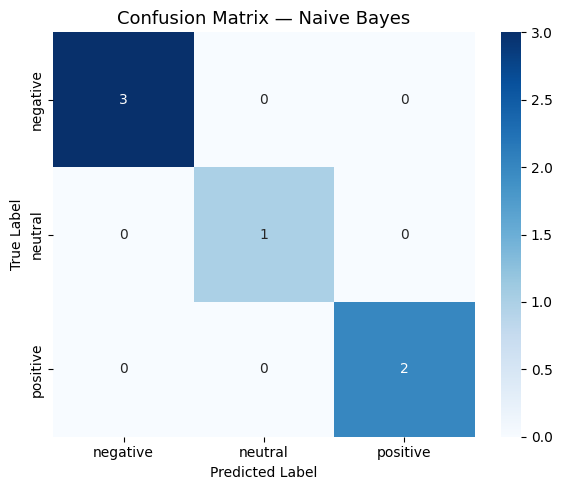

In [29]:
# ── Confusion Matrix — NB ──────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontsize=13)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

class_names = [id2label[i] for i in sorted(id2label)]
plot_confusion_matrix(y_test, y_pred_nb, class_names, 'Confusion Matrix — Naive Bayes')

---
## 🤖 Section 5 — Model 2: Linear SVM

**Why SVM for Arabic?**
- LinearSVC is the go-to for text classification — maximizes margin between classes
- Handles morphological noise better than NB due to soft decision boundary
- `class_weight='balanced'` automatically handles class imbalance
- Often outperforms NB on dialectal Arabic where spelling varies

══════════════════════════════════════════════════
  Model 2: Linear SVM
══════════════════════════════════════════════════
Accuracy : 1.0000
F1 (macro): 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         3
     neutral       1.00      1.00      1.00         1
    positive       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



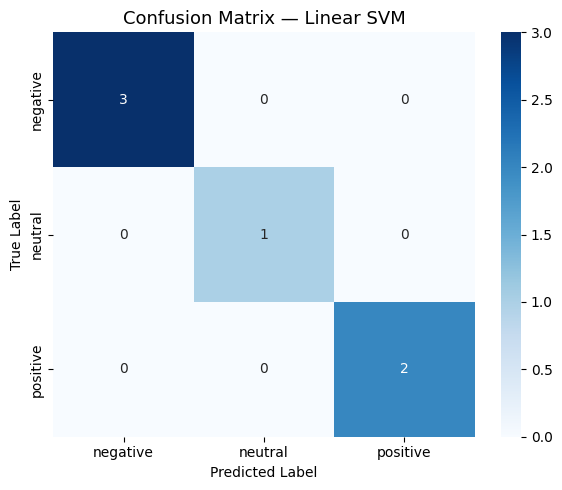

In [30]:
# ── Linear SVM Pipeline ───────────────────────────────────────────────────
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',  # handles class imbalance automatically
        max_iter=2000,
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

print('═' * 50)
print('  Model 2: Linear SVM')
print('═' * 50)
print(f'Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_svm, average="macro", zero_division=0):.4f}')
print()
print(classification_report(
    y_test, y_pred_svm,
    target_names=class_names,
    zero_division=0
))

plot_confusion_matrix(y_test, y_pred_svm, class_names, 'Confusion Matrix — Linear SVM')

In [31]:
# ── Most discriminative features (SVM) ────────────────────────────────────
svm_clf    = svm_pipeline.named_steps['clf']
tfidf_step = svm_pipeline.named_steps['tfidf']
feat_names = tfidf_step.get_feature_names_out()

print('Most discriminative SVM features per class:\n')
for i, class_name in enumerate(svm_clf.classes_):
    coef = svm_clf.coef_[i]
    top10 = coef.argsort()[-10:][::-1]
    print(f'  [{id2label[class_name]}]: ' + ', '.join(feat_names[j] for j in top10))

Most discriminative SVM features per class:

  [negative]: خدمه, سيء, غير, للغايه, سييه, خدمه العملاء, العملاء بطييه, العملاء, بطييه, بطييه جدا
  [neutral]: عاديه, تجربه عاديه, السعر, مرتفع, السعر مرتفع, تجربه, بشكل عام, مقبوله بشكل, مقبوله, تجربه مقبوله
  [positive]: ممتازه, رايع, والخدمه, الغرفه, وانصح, جدا, الاكل شهي, شهي والخدمه, والخدمه جيده, شهي


---
## 🤖 Section 6 — Model 3: AraBERT (Transformer Fine-Tuning)

**Why AraBERT for Arabic?**
- Pre-trained on 70GB+ of Arabic text (Wikipedia, OSCAR, news)
- Understands **context**: يد (hand) vs يد (team)
- Handles morphological richness and dialectal variance
- `arabert-v2` is preferred; `marbert` is better for dialectal Arabic

| Model | Best For |
|-------|----------|
| `aubmindlab/bert-base-arabertv2` | MSA, formal Arabic |
| `UBC-NLP/MARBERT` | Dialectal Arabic |
| `CAMeL-Lab/bert-base-arabic-camelbert-mix` | Mixed MSA + Dialectal |

In [32]:
# ── AraBERT Configuration ──────────────────────────────────────────────────
MODEL_NAME   = 'aubmindlab/bert-base-arabertv2'
NUM_LABELS   = len(label_map)
MAX_LENGTH   = 128   # Most Arabic tweets/reviews fit in 128 tokens
BATCH_SIZE   = 8     # Reduce to 4 if OOM on GPU
LEARNING_RATE = 2e-5
EPOCHS        = 3

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test tokenization on Arabic text
sample_text = 'المنتج رائع جداً'
tokens = tokenizer(sample_text, return_tensors='pt')
decoded = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])
print(f'\nSample tokenization:')
print(f'  Text  : {sample_text}')
print(f'  Tokens: {decoded}')

Loading tokenizer: aubmindlab/bert-base-arabertv2


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Sample tokenization:
  Text  : المنتج رائع جداً
  Tokens: ['[CLS]', 'المن', '##تج', 'رائع', '[UNK]', '[SEP]']


In [33]:
# ── Prepare HuggingFace Dataset ────────────────────────────────────────────
def tokenize_fn(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding=False,        # dynamic padding via DataCollatorWithPadding
        max_length=MAX_LENGTH
    )

train_df = pd.DataFrame({'text': X_train.values, 'labels': y_train.values})
test_df  = pd.DataFrame({'text': X_test.values,  'labels': y_test.values})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False)

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=['text'])
test_ds  = test_ds.map(tokenize_fn, batched=True, remove_columns=['text'])

print(f'Train dataset: {train_ds}')
print(f'Test  dataset: {test_ds}')

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Train dataset: Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 24
})
Test  dataset: Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6
})


In [34]:
# ── Load AraBERT Model ─────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label_map,
)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters: 135,195,651


In [35]:
# ── Training Arguments ────────────────────────────────────────────────────
import numpy as np
from transformers import EarlyStoppingCallback

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
    }

training_args = TrainingArguments(
    output_dir='./arabert_outputs',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.1,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir='./logs',
    logging_steps=10,
    fp16=False,   # set True if CUDA GPU available
    report_to='none',
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('✅ Trainer configured. Run trainer.train() to start fine-tuning.')

✅ Trainer configured. Run trainer.train() to start fine-tuning.


In [ ]:
# ── Fine-tune AraBERT ──────────────────────────────────────────────────────
# ⚠️  This cell requires a GPU for practical training times.
#      On a T4 GPU (Google Colab free tier) with a 10k dataset:
#      ~3 epochs ≈ 5-10 minutes.
#      On CPU only: may take 30+ minutes — consider reducing EPOCHS=1.

train_result = trainer.train()
print(f'Training complete!')
print(f'Training loss: {train_result.training_loss:.4f}')

══════════════════════════════════════════════════
  Model 3: AraBERT (Fine-tuned)
══════════════════════════════════════════════════
Accuracy : 0.3333
F1 (macro): 0.1667

              precision    recall  f1-score   support

    negative       0.40      0.67      0.50         3
     neutral       0.00      0.00      0.00         1
    positive       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.13      0.22      0.17         6
weighted avg       0.20      0.33      0.25         6



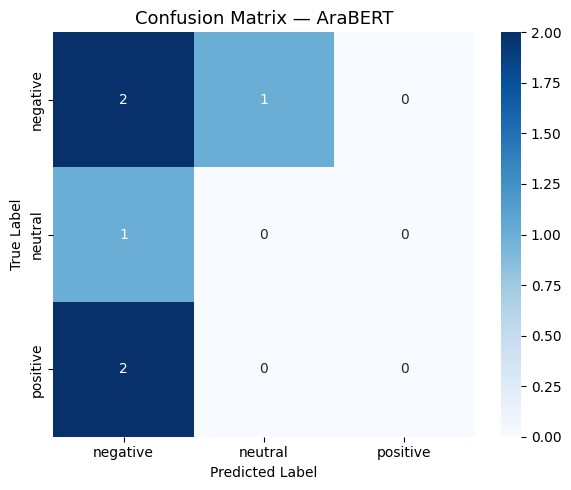

In [36]:
# ── Evaluate AraBERT on Test Set ──────────────────────────────────────────
arabert_preds = trainer.predict(test_ds)
y_pred_bert   = np.argmax(arabert_preds.predictions, axis=-1)

print('═' * 50)
print('  Model 3: AraBERT (Fine-tuned)')
print('═' * 50)
print(f'Accuracy : {accuracy_score(y_test, y_pred_bert):.4f}')
print(f'F1 (macro): {f1_score(y_test, y_pred_bert, average="macro", zero_division=0):.4f}')
print()
print(classification_report(
    y_test, y_pred_bert,
    target_names=class_names,
    zero_division=0
))

plot_confusion_matrix(y_test, y_pred_bert, class_names, 'Confusion Matrix — AraBERT')

---
## 🏷️ Section 7 — Additional Classification Tasks

The same pipeline generalizes to multiple Arabic NLP classification tasks. Below are dataset and configuration notes for each task — swap `df` and `label_map` accordingly.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  TASK 2: Topic / News Classification (تصنيف المواضيع)
# ══════════════════════════════════════════════════════════════════════════
#
#  Datasets: OSAC (22k docs), Khaleej-2004, ANSAr
#  Labels  : رياضة، سياسة، اقتصاد، ثقافة، تقنية
#
#  Key differences vs sentiment:
#   - More classes (5-20) → macro-F1 is more important than accuracy
#   - Vocabulary is domain-specific → larger TF-IDF vocabulary
#   - Class sizes often unbalanced → class_weight='balanced' in SVM
#
#  To switch tasks:
#    df = pd.read_csv('osac_news.csv')   # columns: text, category
#    label_map = {cat: i for i, cat in enumerate(df['category'].unique())}
#    # Then re-run from Section 3 onward

print('''
Topic Classification Task Notes
─────────────────────────────────
Dataset  : OSAC corpus / Khaleej-2004
Labels   : Sports, Politics, Economy, Culture, Technology
Best model: LinearSVC with bigrams (fast, accurate on MSA news)
AraBERT model recommendation: aubmindlab/bert-base-arabertv2
''')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  TASK 3: Arabic Dialect Identification (تحديد اللهجة)
# ══════════════════════════════════════════════════════════════════════════
#
#  Dataset  : MADAR corpus (25 city-level Arabic dialects + MSA)
#             ADI (5-way: Egyptian, Gulf, Levantine, North African, MSA)
#  Challenge: High confusion between geographically similar dialects
#  Best model: MARBERT (pre-trained on 1B dialectal tweets)
#
#  Character-level n-grams are CRITICAL here because:
#   - Dialectal spelling is not standardized
#   - Character patterns (ش vs. ت suffix, ق→ء in Egyptian) distinguish dialects

char_tfidf = TfidfVectorizer(
    analyzer='char_wb',      # character-level within word boundaries
    ngram_range=(2, 5),      # character 2-5-grams
    min_df=1,
    max_features=100_000,
    sublinear_tf=True,
)

print('''
Dialect Identification Task Notes
───────────────────────────────────
Dataset  : MADAR / ADI corpus
Labels   : Egyptian, Gulf, Levantine, North African, MSA
Key trick : Use character-level TF-IDF (char_wb, 2-5 grams)
Best model: MARBERT (UBC-NLP/MARBERT) — pre-trained on dialectal tweets
''')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  TASK 4: Offensive / Hate Speech Detection (كشف خطاب الكراهية)
# ══════════════════════════════════════════════════════════════════════════
#
#  Dataset  : OSACT4, L-HSAB, ArAbOffensive
#  Labels   : Offensive / Not-Offensive  (or fine-grained: vulgar, hate, normal)
#  Challenge: Severe class imbalance (offensive << normal)
#  Strategy : SMOTE or class_weight='balanced' + high recall target
#
#  Note: Do NOT strip ALL stop words — negation words (لا، ما، لن)
#        are crucial for understanding offensive intent.

print('''
Offensive Language Detection Task Notes
─────────────────────────────────────────
Dataset  : OSACT4 / L-HSAB
Labels   : Offensive, Not Offensive
Key trick : Keep negation words (لا، ما، لن) — do not remove
Metric   : Prioritize Recall (minimize False Negatives)
Best model: AraBERT fine-tuned + class_weight adjustment
''')

---
## 📊 Section 8 — Model Comparison & Final Evaluation

In [37]:
# ── Model comparison table ─────────────────────────────────────────────────
# Replace placeholder scores with actual results after running all models

results = {
    'Model': ['Naive Bayes', 'Linear SVM', 'AraBERT'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_nb), 4),
        round(accuracy_score(y_test, y_pred_svm), 4),
        round(accuracy_score(y_test, y_pred_bert), 4),
    ],
    'F1 (Macro)': [
        round(f1_score(y_test, y_pred_nb, average='macro', zero_division=0), 4),
        round(f1_score(y_test, y_pred_svm, average='macro', zero_division=0), 4),
        round(f1_score(y_test, y_pred_bert, average='macro', zero_division=0), 4),
    ],
    'Speed': ['⚡ Fast', '⚡ Fast', '🐢 Slow (GPU recommended)'],
    'Use When': [
        'Quick baseline, MSA formal text',
        'Best classical model, handles imbalance',
        'Highest accuracy, has GPU, contextual'
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      Model  Accuracy  F1 (Macro)                    Speed                                Use When
Naive Bayes    1.0000      1.0000                   ⚡ Fast         Quick baseline, MSA formal text
 Linear SVM    1.0000      1.0000                   ⚡ Fast Best classical model, handles imbalance
    AraBERT    0.3333      0.1667 🐢 Slow (GPU recommended)   Highest accuracy, has GPU, contextual


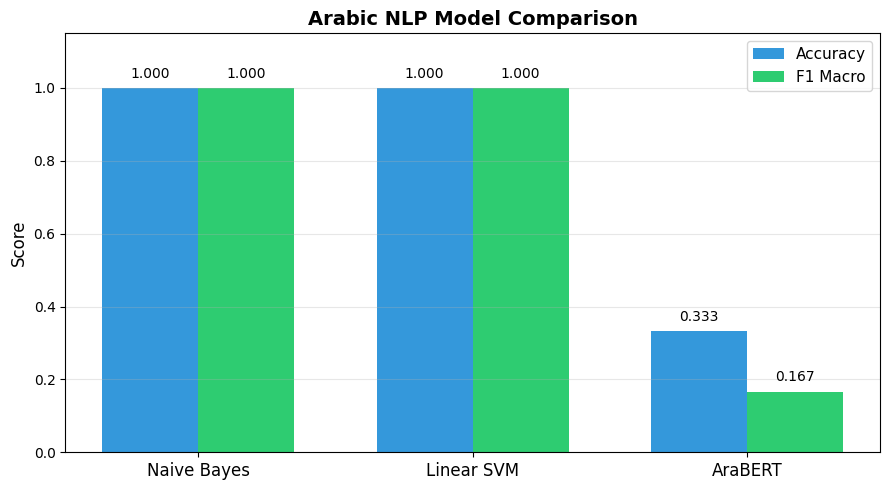

In [38]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'],  width, label='Accuracy',  color='#3498db')
bars2 = ax.bar(x + width/2, results_df['F1 (Macro)'], width, label='F1 Macro', color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Arabic NLP Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---
## 🏆 Section 9 — Best Practices Summary

| Stage | Arabic-Specific Best Practice |
|-------|------------------------------|
| **Data** | Use ASTD / HARD / OSAC for benchmarking; check for dialectal mixing |
| **Normalization** | Always remove diacritics, normalize Alef/Hamza, remove Tatweel |
| **Stop Words** | Keep negation (لا، ما، لن) for sentiment tasks |
| **Tokenization** | Use CAMeL Tools for MSA; AraBERT tokenizer for transformer models |
| **Stemming** | Prefer light stemming (ISRIStemmer) over aggressive; avoid for BERT |
| **Vectorization** | char-ngrams (2-5) for dialects; word TF-IDF for MSA |
| **Baseline** | Always run Naive Bayes first; a surprisingly strong baseline |
| **Class Imbalance** | Use `class_weight='balanced'` in SVM; augment with EDA for BERT |
| **Model Selection** | MSA formal → AraBERT; Dialectal → MARBERT; Mixed → CamelBERT |
| **Evaluation** | Use **macro-F1** — accuracy is misleading on imbalanced Arabic datasets |
| **Data Leakage** | Fit vectorizer ONLY on training split; transform test separately |

In [39]:
# ── Quick Inference Function ───────────────────────────────────────────────
def predict_arabic(
    text: str,
    model_choice: str = 'svm'
) -> dict:
    """
    Predict sentiment/label for a new Arabic text.

    Args:
        text        : Raw Arabic string
        model_choice: 'nb', 'svm', or 'bert'

    Returns:
        dict with 'text', 'clean_text', 'predicted_label'
    """
    clean = arabic_preprocess(text)

    if model_choice == 'nb':
        pred_id = nb_pipeline.predict([clean])[0]
    elif model_choice == 'svm':
        pred_id = svm_pipeline.predict([clean])[0]
    elif model_choice == 'bert':
        enc = tokenizer(clean, return_tensors='pt',
                        truncation=True, max_length=MAX_LENGTH)
        import torch
        with torch.no_grad():
            out = model(**enc)
        pred_id = out.logits.argmax(-1).item()
    else:
        raise ValueError(f'Unknown model: {model_choice}')

    return {
        'text'           : text,
        'clean_text'     : clean,
        'predicted_label': id2label[pred_id],
    }


# ── Demo ──────────────────────────────────────────────────────────────────
test_inputs = [
    'المنتج ممتاز وسعره مناسب جداً',
    'لن أعود لهذا المطعم أبداً، الطعام كان سيئاً',
    'الخدمة لا بأس بها والسعر معقول',
]

print('=== SVM Inference Demo ===')
for txt in test_inputs:
    result = predict_arabic(txt, model_choice='svm')
    print(f'  [{result["predicted_label"]:>8}] {txt}')

=== SVM Inference Demo ===
  [positive] المنتج ممتاز وسعره مناسب جداً
  [negative] لن أعود لهذا المطعم أبداً، الطعام كان سيئاً
  [ neutral] الخدمة لا بأس بها والسعر معقول


In [ ]:
# ── Save Models ────────────────────────────────────────────────────────────
import pickle

# Save NB and SVM pipelines
with open('nb_pipeline_arabic.pkl', 'wb') as f:
    pickle.dump(nb_pipeline, f)

with open('svm_pipeline_arabic.pkl', 'wb') as f:
    pickle.dump(svm_pipeline, f)

# Save AraBERT model + tokenizer
model.save_pretrained('./arabert_sentiment')
tokenizer.save_pretrained('./arabert_sentiment')

print('✅ All models saved successfully')
print('   • nb_pipeline_arabic.pkl')
print('   • svm_pipeline_arabic.pkl')
print('   • ./arabert_sentiment/')

# 🚀 Advanced & Alternative Architectures

If the classical machine learning baseline established above (e.g., **Naive Bayes**, **SVM**) is insufficient for your deployment needs, the NLP ecosystem offers powerful deep learning alternatives.

Once a baseline is stable, transitioning to **pre-trained transformer models** is the optimal strategy to:
- Capture deep contextual meaning  
- Understand semantic relationships  
- Handle complex linguistic patterns  

---

## 🧠 Deep Learning & Transformer Models for Arabic

### 🔹 AraBERT / MARBERT
Using the Hugging Face ecosystem, you can fine-tune:

- **AraBERT** → designed specifically for Arabic text  
- **MARBERT** → optimized for Arabic dialects and social media  

These models process text **bi-directionally**, allowing them to:
- Understand Arabic morphology  
- Capture subtle semantic nuances  

---

### 🔹 CamelBERT
A collection of pre-trained models tailored for different Arabic varieties:

- Modern Standard Arabic (MSA)  
- Egyptian dialect  
- Gulf dialect  
- Other regional variants  

✅ Especially useful when your dataset is **dialect-specific**

---

### 🔹 ByT5 / mT5 (Multilingual Sequence-to-Sequence)

Ideal for more advanced or non-standard tasks:

- Generative classification  
- Noisy or messy text  
- Character-level modeling  

These models are particularly effective for:
- Custom triage systems  
- Routing agents  
- Complex NLP pipelines  

---

## 🎯 Summary

- Start with **classical ML** → fast and simple baseline  
- Move to **transformers** → when you need higher accuracy and deeper understanding  
- Choose model based on:
  - Language type (MSA vs dialect)
  - Task complexity
  - Data quality

---
## 📚 References & Arabic NLP Resources

### Datasets
- **ASTD** — Arabic Sentiment Tweets Dataset: [github.com/mahmoudnabil/ASTD](https://github.com/mahmoudnabil/ASTD)
- **HARD** — Hotel Arabic-Reviews Dataset: [github.com/elnagara/HARD-Arabic-Dataset](https://github.com/elnagara/HARD-Arabic-Dataset)
- **OSAC** — Open Source Arabic Corpora: [sourceforge.net/projects/ar-text-mining](https://sourceforge.net/projects/ar-text-mining)
- **MADAR** — Multi-Arabic Dialect Applications and Resources: [camel.abudhabi.nyu.edu/madar](https://camel.abudhabi.nyu.edu/madar)
- **ArSAS** — Arabic Sarcasm Detection: [qcri.org](https://www.qcri.org)

### Pre-trained Models
- **AraBERT v2**: `aubmindlab/bert-base-arabertv2`
- **MARBERT**: `UBC-NLP/MARBERT` (dialectal)
- **CamelBERT**: `CAMeL-Lab/bert-base-arabic-camelbert-mix`
- **AraGPT2**: `aubmindlab/aragpt2-base`

### Tools
- **CAMeL Tools**: `pip install camel-tools` — morphological analysis, tokenization
- **PyArabic**: `pip install pyarabic` — normalization, diacritics
- **Farasa**: Java-based Arabic NLP suite (segmentation, POS, NER)
- **Hugging Face**: [huggingface.co/models?language=ar](https://huggingface.co/models?language=ar)

### Papers
- Antoun et al. (2020) — AraBERT: Transformer-based Model for Arabic Language Understanding
- Bouamor et al. (2019) — The MADAR Arabic Dialect Corpus and Lexicon
- Farha & Magdy (2019) — Mazajak: An Online Arabic Sentiment Analyser